# TorchRef Target Exploration

This notebook explores the different refinement targets available in TorchRef and analyzes their calculation times.

## Setup

In [1]:
import torch
import time
import torchref
from torchref import ROOT_TORCHREF
from torchref.refinement import LBFGSRefinement

# File paths
mtzpath = f'{ROOT_TORCHREF}/example_notebooks/1DAW.mtz'
pdbpath = f'{ROOT_TORCHREF}/example_notebooks/1DAW.pdb'

# Initialize refinement
refinement = LBFGSRefinement(
    data_file=mtzpath,
    pdb=pdbpath,
)

/tmp/ipykernel_1960206/3829561953.py:3: UserWarning: TorchRef auto-configured 4 threads. Set TORCHREF_NUM_THREADS to override.
  import torchref


FrenchWilsonModule initialized:
  Reflections: 23356
  Resolution: 2.05 - 69.56 Å
  Space group: <gemmi.SpaceGroup("C 1 2 1")>
  Centric: 1125 (4.8%)
found nan F values:  0
found nan F_sigma values:  0
Suspicious sigma detection: 0/23356 (0.00%) reflections flagged
Loaded 3051 atoms
Parametrization built for 6 unique atom types
MapSymmetry: Using direct indexing (no interpolation) for <gemmi.SpaceGroup("C 1 2 1")>
MapSymmetryDirect initialized for <gemmi.SpaceGroup("C 1 2 1")>
  Number of symmetry operations: 4
  Map shape: (160, 72, 54)
  ✓ Using direct indexing (no interpolation)
Initialized Scaler with 10 bins.
Found 109 link definitions
Built 326 peptide bond restraints
Built 978 peptide angle restraints
Built 326 peptide plane restraints

Building VDW (non-bonded) restraints...
  Built 28724 VDW restraints (all contacts)
Restraints Summary (New Implementation)
CIF file: None
Residue types in dictionary: 21

INTRA-RESIDUE RESTRAINTS:
------------------------------------------------

## List All Available Targets

Targets are registered in the LossState object. Let's see what targets are available.

In [2]:
# Create loss state with all registered targets
loss_state = refinement.create_loss_state()

print("Registered Targets:")
print("=" * 50)
for i, name in enumerate(loss_state.targets.keys(), 1):
    print(f"{i:2d}. {name}")

print(f"\nTotal: {len(loss_state.targets)} targets")

Registered Targets:
 1. xray
 2. geometry/bond
 3. geometry/angle
 4. geometry/torsion
 5. geometry/planarity
 6. geometry/chiral
 7. geometry/nonbonded
 8. adp/simu
 9. adp/locality
10. adp/KL

Total: 10 targets


## Target Breakdown by Group

Targets are organized hierarchically (e.g., `geometry/bond`, `adp/simu`). Let's see the groupings.

In [3]:
from collections import defaultdict

# Group targets by their prefix
groups = defaultdict(list)
for name in loss_state.targets.keys():
    parts = name.split('/')
    group = parts[0] if len(parts) > 1 else 'root'
    component = '/'.join(parts[1:]) if len(parts) > 1 else parts[0]
    groups[group].append(component)

print("Targets by Group:")
print("=" * 50)
for group, components in groups.items():
    print(f"\n{group.upper()}:")
    for comp in components:
        print(f"  - {comp}")

Targets by Group:

ROOT:
  - xray

GEOMETRY:
  - bond
  - angle
  - torsion
  - planarity
  - chiral
  - nonbonded

ADP:
  - simu
  - locality
  - KL


## Evaluate Targets and View Values

Let's compute all target values and see the loss breakdown.

In [4]:
# Populate target info and compute losses
refinement.add_target_info_to_state(loss_state)
refinement.populate_state_meta(loss_state)


# Load default hyperparameters this is done for demonstration and happens automatically in normal usage in setup_comp[]
from torchref.utils.utils import json_to_state_dicts_separate
from torchref import PATH_TORCHREF_DATA
import os

hyperparams_path = os.path.join(PATH_TORCHREF_DATA, 'default_hyperparameters.json')
component_weighting_state, geometry_target_state, adp_target_state, unassigned_keys = json_to_state_dicts_separate(hyperparams_path)

refinement.component_weighting.load_state_dict(component_weighting_state, strict=False)
refinement.geometry_target.load_state_dict(geometry_target_state, strict=False)
refinement.adp_target.load_state_dict(adp_target_state, strict=False)

refinement.update_weights(loss_state)


# Aggregate to compute all losses
total_loss = loss_state.aggregate()

# Get breakdown
breakdown = loss_state.get_breakdown()

print("Loss Breakdown:")
print("=" * 70)
print(f"{'Target':<35} {'Loss':>12} {'Weight':>10} {'Weighted':>12}")
print("-" * 70)

for group, components in breakdown.items():
    print(f"\n[{group}]")
    for comp, values in components.items():
        full_name = f"{group}/{comp}" if group != 'root' else comp
        print(f"  {comp:<33} {values['loss']:>12.4f} {values['weight']:>10.4f} {values['weighted']:>12.4f}")

print("-" * 70)
print(f"{'TOTAL':<35} {'':<12} {'':<10} {total_loss.item():>12.4f}")

Loss Breakdown:
Target                                      Loss     Weight     Weighted
----------------------------------------------------------------------

[root]
  xray                                   54.6483     0.5200      28.4149

[geometry]
  bond                                   -2.2158  2419.0632   -5360.0830
  angle                                  -1.0222  2724.5205   -2785.0791
  torsion                                 0.8729  2299.9653    2007.6240
  planarity                              -2.3003 33656.9852  -77420.8984
  chiral                                 -0.4959 186549.0549  -92516.9453
  nonbonded                               0.0513  2270.1408     116.4095

[adp]
  simu                                    3.9170  5239.8340   20524.4590
  locality                                0.1853  2756.1947     510.6027
  KL                                      0.3759  2848.0381    1070.5521
----------------------------------------------------------------------
TOTAL      

In [5]:
# Weighting based on a learned policy (shallow neural network trained through an Evolutionary Strategy)

Policy_path = f'{ROOT_TORCHREF}/torchref/data/policy_latest.pt'
print(f"\nLoading policy weighting from: {Policy_path}")
from torchref.refinement.weighting.policy_weighting import PolicyComponentWeighting
policy_weighting = PolicyComponentWeighting(policy_path=str(Policy_path))

refinement.component_weighting = policy_weighting


loss_state = refinement.create_loss_state()

refinement.populate_state_meta(loss_state)
refinement.add_target_info_to_state(loss_state)
refinement.update_weights(loss_state)

# Aggregate to compute all losses
total_loss = loss_state.aggregate()

# Get breakdown
breakdown = loss_state.get_breakdown()

print("Loss Breakdown:")
print("=" * 70)
print(f"{'Target':<35} {'Loss':>12} {'Weight':>10} {'Weighted':>12}")
print("-" * 70)

for group, components in breakdown.items():
    print(f"\n[{group}]")
    for comp, values in components.items():
        full_name = f"{group}/{comp}" if group != 'root' else comp
        print(f"  {comp:<33} {values['loss']:>12.4f} {values['weight']:>10.4f} {values['weighted']:>12.4f}")

print("-" * 70)
print(f"{'TOTAL':<35} {'':<12} {'':<10} {total_loss.item():>12.4f}")




Loading policy weighting from: /das/work/units/LBR-FEL/p17490/Peter/Library/torchref/torchref/data/policy_latest.pt
Loss Breakdown:
Target                                      Loss     Weight     Weighted
----------------------------------------------------------------------

[root]
  xray                                   54.6483     0.0498       2.7225

[geometry]
  bond                                   -2.2158    20.0855     -44.5049
  angle                                  -1.0222    20.0559     -20.5017
  torsion                                 0.8729     0.0498       0.0435
  planarity                              -2.3003    20.0855     -46.2026
  chiral                                 -0.4959     1.4258      -0.7071
  nonbonded                               0.0513     0.0498       0.0026

[adp]
  simu                                    3.9170     0.0503       0.1970
  locality                                0.1853     0.0498       0.0092
  KL                                   

Weighting schemes are the main secret sauce in modern crystallogrpahy. They control which information source is given what value and how the final structure should look. The main weighting scheme in the refinement, uses target offset weighting where all the regularization losses are given a certain target value. The weight is then calculated as the offset of the actual loss value from the target value. 

The parameter for this approach were finetuned to produce a low output rfree using an There is an experimental implementation of policy based weighting trained by an Evolutionary style algorithm. In both cases the xray data gets weighed down significantly compared to the other loss sources.

These weighting schemes are subject to change but alreday have good control of the refinement. 

## Group Totals

In [6]:
group_totals = loss_state.get_group_totals()

print("Weighted Loss by Group:")
print("=" * 40)
for group, total in sorted(group_totals.items(), key=lambda x: -x[1]):
    print(f"{group:<20} {total:>15.4f}")

Weighted Loss by Group:
xray                          2.7225
adp                           0.2250
geometry                   -111.8703


## Target Calculation Timing

Now let's measure how long each target takes to compute. This is useful for understanding performance bottlenecks.

In [12]:
import pandas as pd

refinement.cpu()

# Number of iterations for timing
n_iterations = 100

# Ensure we're on CPU for fair comparison (or use CUDA sync if on GPU)
device = refinement.model.xyz.device
use_cuda = device.type == 'cuda'

timing_results = []

print(f"Timing each target ({n_iterations} iterations)...")
print(f"Device: {device}")
print("=" * 60)

for name, target in loss_state.targets.items():
    times = []
    
    for _ in range(n_iterations):
        if use_cuda:
            torch.cuda.synchronize()
        
        start = time.perf_counter()
        _ = target()
        
        if use_cuda:
            torch.cuda.synchronize()
        
        end = time.perf_counter()
        if i == 1:
            continue  # Skip first iteration for warm-up
        times.append((end - start) * 1000)  # Convert to ms
    
    avg_time = sum(times) / len(times)
    min_time = min(times)
    max_time = max(times)
    
    timing_results.append({
        'target': name,
        'avg_ms': avg_time,
        'min_ms': min_time,
        'max_ms': max_time
    })

# Create DataFrame and sort by average time
df = pd.DataFrame(timing_results)
df = df.sort_values('avg_ms', ascending=False)

# Calculate percentage of total time
total_time = df['avg_ms'].sum()
df['pct'] = (df['avg_ms'] / total_time * 100).round(1)

print(f"\n{'Target':<35} {'Avg (ms)':>10} {'Min':>10} {'Max':>10} {'% Total':>10}")
print("-" * 75)
for _, row in df.iterrows():
    print(f"{row['target']:<35} {row['avg_ms']:>10.3f} {row['min_ms']:>10.3f} {row['max_ms']:>10.3f} {row['pct']:>9.1f}%")

print("-" * 75)
print(f"{'TOTAL':<35} {total_time:>10.3f}")

Model moved to device: cpu
Timing each target (100 iterations)...
Device: cpu

Target                                Avg (ms)        Min        Max    % Total
---------------------------------------------------------------------------
xray                                    92.231     52.179    202.074      79.1%
geometry/planarity                      10.920      5.455     68.821       9.4%
geometry/nonbonded                       3.652      0.793     64.211       3.1%
adp/locality                             2.934      0.733    107.084       2.5%
geometry/torsion                         1.804      1.371     40.430       1.5%
geometry/angle                           1.665      0.702     45.861       1.4%
geometry/chiral                          1.107      0.459     63.519       1.0%
adp/simu                                 1.058      0.407     63.379       0.9%
geometry/bond                            0.917      0.432     45.607       0.8%
adp/KL                                   0.24

## Timing Visualization

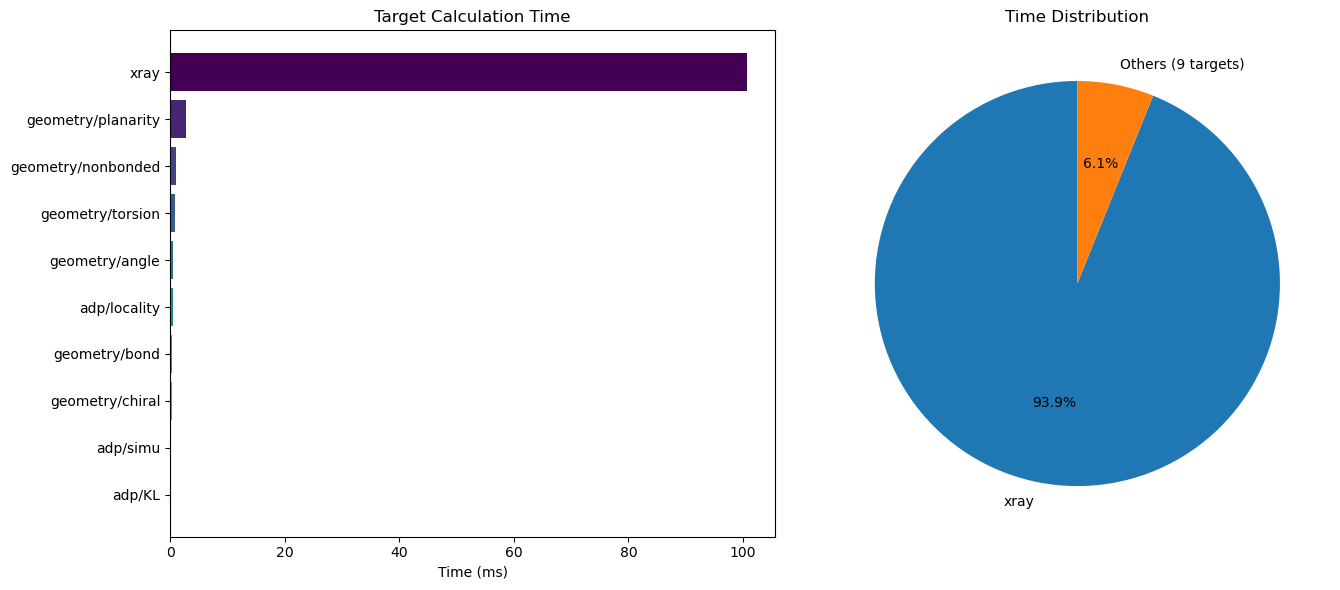

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of timing
ax1 = axes[0]
colors = plt.cm.viridis(range(0, 256, 256 // len(df)))
bars = ax1.barh(df['target'], df['avg_ms'], color=colors)
ax1.set_xlabel('Time (ms)')
ax1.set_title('Target Calculation Time')
ax1.invert_yaxis()

# Pie chart of time distribution
ax2 = axes[1]
# Group small values for readability
threshold = 5  # percent
major = df[df['pct'] >= threshold]
minor = df[df['pct'] < threshold]

if len(minor) > 0:
    pie_data = list(major['avg_ms']) + [minor['avg_ms'].sum()]
    pie_labels = list(major['target']) + [f'Others ({len(minor)} targets)']
else:
    pie_data = list(df['avg_ms'])
    pie_labels = list(df['target'])

ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Time Distribution')

plt.tight_layout()
plt.show()

The calculation time is dominated by calcualtion and evaluation of the strcuture factor. This is acclerated quite a bit by moving to gpu

In [11]:
import pandas as pd

refinement.cuda()

# Number of iterations for timing
n_iterations = 100

# Ensure we're on CPU for fair comparison (or use CUDA sync if on GPU)
device = refinement.model.xyz.device
use_cuda = device.type == 'cuda'

timing_results = []

print(f"Timing each target ({n_iterations} iterations)...")
print(f"Device: {device}")
print("=" * 60)

for name, target in loss_state.targets.items():
    times = []
    
    for i in range(n_iterations):
        if use_cuda:
            torch.cuda.synchronize()
        
        start = time.perf_counter()
        _ = target()
        
        if use_cuda:
            torch.cuda.synchronize()
        
        end = time.perf_counter()
        if i == 1:
            continue  # Skip first iteration for warm-up
        times.append((end - start) * 1000)  # Convert to ms
    
    avg_time = sum(times) / len(times)
    min_time = min(times)
    max_time = max(times)
    
    timing_results.append({
        'target': name,
        'avg_ms': avg_time,
        'min_ms': min_time,
        'max_ms': max_time
    })

# Create DataFrame and sort by average time
df_gpu = pd.DataFrame(timing_results)
df_gpu = df_gpu.sort_values('avg_ms', ascending=False)

# Calculate percentage of total time
total_time = df_gpu['avg_ms'].sum()
df_gpu['pct'] = (df_gpu['avg_ms'] / total_time * 100).round(1)

print(f"\n{'Target':<35} {'Avg (ms)':>10} {'Min':>10} {'Max':>10} {'% Total':>10}")
print("-" * 75)
for _, row in df_gpu.iterrows():
    print(f"{row['target']:<35} {row['avg_ms']:>10.3f} {row['min_ms']:>10.3f} {row['max_ms']:>10.3f} {row['pct']:>9.1f}%")

print("-" * 75)
print(f"{'TOTAL':<35} {total_time:>10.3f}")

Model moved to device: cuda
Timing each target (100 iterations)...
Device: cuda:0

Target                                Avg (ms)        Min        Max    % Total
---------------------------------------------------------------------------
xray                                    13.038     12.474     16.218      57.8%
geometry/planarity                       4.362      4.071      4.729      19.3%
geometry/torsion                         1.686      1.646      1.905       7.5%
geometry/angle                           0.697      0.678      0.751       3.1%
geometry/chiral                          0.627      0.600      0.802       2.8%
adp/simu                                 0.510      0.486      0.614       2.3%
geometry/bond                            0.494      0.480      0.649       2.2%
adp/locality                             0.479      0.460      0.546       2.1%
geometry/nonbonded                       0.386      0.369      0.462       1.7%
adp/KL                                   

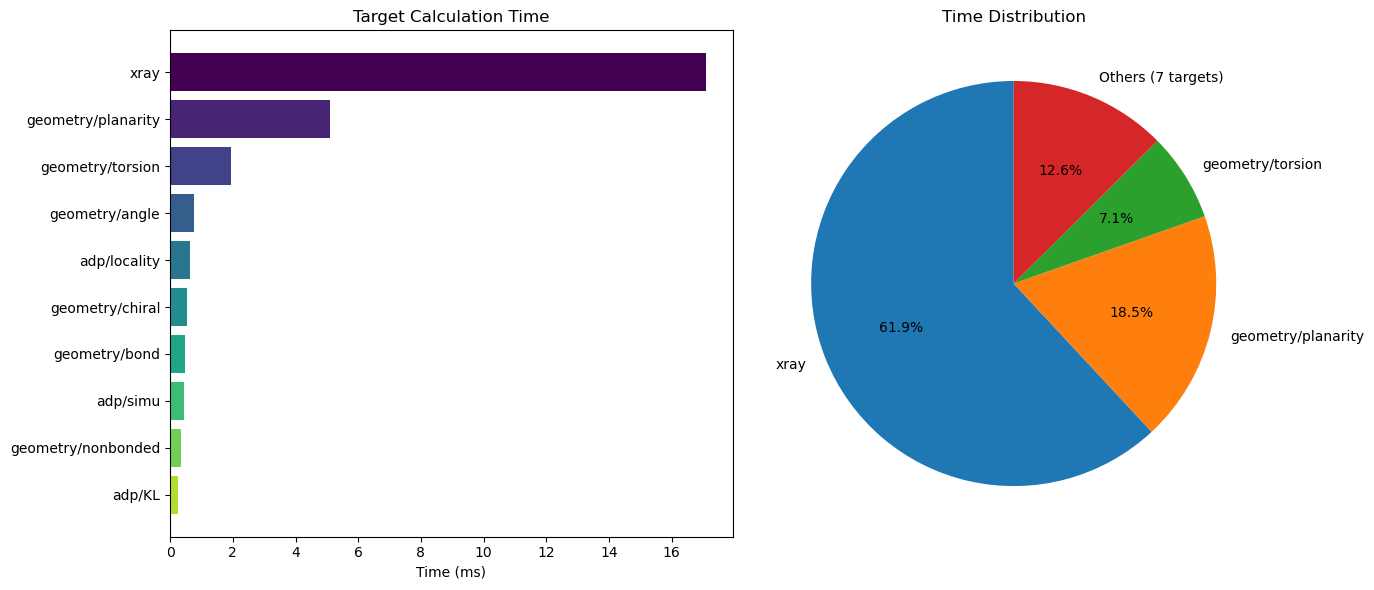

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart of timing
ax1 = axes[0]
colors = plt.cm.viridis(range(0, 256, 256 // len(df_gpu)))
bars = ax1.barh(df_gpu['target'], df_gpu['avg_ms'], color=colors)
ax1.set_xlabel('Time (ms)')
ax1.set_title('Target Calculation Time')
ax1.invert_yaxis()

# Pie chart of time distribution
ax2 = axes[1]
# Group small values for readability
threshold = 5  # percent
major = df_gpu[df_gpu['pct'] >= threshold]
minor = df_gpu[df_gpu['pct'] < threshold]

if len(minor) > 0:
    pie_data = list(major['avg_ms']) + [minor['avg_ms'].sum()]
    pie_labels = list(major['target']) + [f'Others ({len(minor)} targets)']
else:
    pie_data = list(df_gpu['avg_ms'])
    pie_labels = list(df_gpu['target'])

ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Time Distribution')

plt.tight_layout()
plt.show()

Running on GPU times are still dominated by strcuture factor calculation but the overhead is significantly smaller. There are possible future optimisations but for now it is fast enough. 